In [10]:

import cmdstanpy
import numpy as np
import pandas as pd 
from scipy.special import expit  # inverse logit
from scipy.special import logit  # inverse logit

In [11]:
df = pd.read_csv("forstmann.csv")

df["correct"] = df.apply(lambda row: 1 if row["S"] == row["R"] else 0,axis = 1)
df['participant_id'], participant_labels = pd.factorize(df['subjects'])
df['participant_id'] += 1  

sat_map = {"speed":1,"neutral":2,"accuracy":3}
df["sat_int"] = df["E"].map(sat_map)
df["pc"] = (df["participant_id"]-1)*3 + df["sat_int"]
df

,subjects,E,S,R,rt,correct,participant_id,sat_int,pc
0,as1t,accuracy,right,right,0.4319,1,1,3,3
1,as1t,speed,right,right,0.5015,1,1,1,1
2,as1t,speed,left,left,0.3104,1,1,1,1
3,as1t,accuracy,right,right,0.4809,1,1,3,3
4,as1t,accuracy,left,left,0.3415,1,1,3,3
...,...,...,...,...,...,...,...,...,...
15813,zk1t,speed,right,right,0.3244,1,19,1,55
15814,zk1t,neutral,left,left,0.5800,1,19,2,56
15815,zk1t,neutral,left,left,0.9199,1,19,2,56
15816,zk1t,accuracy,left,right,0.6314,0,19,3,57


In [12]:
max_rt = (df.groupby(['participant_id','sat_int'])["rt"].max())
max_rt

participant_id  sat_int
1               1          0.7979
                2          1.1555
                3          0.9912
2               1          0.6489
                2          1.1242
                3          1.3960
3               1          0.8129
                2          1.4322
                3          1.4769
4               1          0.7022
                2          0.8110
                3          1.0007
5               1          0.6481
                2          0.9952
                3          1.4364
6               1          0.9039
                2          0.9092
                3          1.3001
7               1          1.2651
                2          1.2043
                3          1.4077
8               1          1.2592
                2          1.3809
                3          1.3834
9               1          1.3234
                2          1.1941
                3          1.2196
10              1          0.8278
                2       

In [13]:
N_correct = len(df[df["correct"] == 1])
N_false = len(df[df["correct"] == 0])
P = 19

rt_correct = list(df[df["correct"]==1]["rt"])
rt_false = list(df[df["correct"]==0]["rt"])
pc_correct = list(df[df["correct"]==1]["pc"])
pc_false = list(df[df["correct"]==0]["pc"])

t0_hi = df.groupby('participant_id')['rt'].quantile(0.05).reindex(range(1, P + 1))

max_rt = (
    df.groupby('pc')['rt']
    .max()
    .reindex(range(1, 3 * P + 1))  # was groupby(['participant_id','sat_int']) - fragile, see earlier note
)
assert max_rt.notna().all(), "some cell has zero trials in max_rt"

print(N_correct, N_false, rt_false)

data = {
    "N_correct": N_correct, "N_false": N_false, "P": P,
    "rt_correct": rt_correct, "rt_false": rt_false,
    "pc_correct": pc_correct, "pc_false": pc_false,
    "max_rt": max_rt.to_numpy(), "t0_hi": t0_hi.to_numpy(),
}

from cmdstanpy import CmdStanModel

model = CmdStanModel(stan_file='SRDM_pkpf_hierarchical.stan')  # <- the r/p_lapse-collapsed version

13294 2524 [0.3111, 0.4118, 0.4343, 0.3286, 0.4872, 0.321, 0.4179, 0.6087, 0.3561, 0.5971, 0.4731, 0.7205, 0.4949, 0.4222, 0.3304, 0.5636, 0.2693, 0.2952, 0.3923, 0.4207, 0.3172, 0.3472, 0.4619, 0.5878, 0.4227, 0.4178, 0.7814, 0.4248, 0.4782, 0.2508, 0.3542, 0.2742, 0.4646, 0.5855, 0.4592, 0.5876, 0.4358, 0.3632, 0.5256, 0.6568, 0.6033, 0.5813, 0.3321, 0.6356, 0.3355, 0.6077, 0.6896, 0.4748, 0.4662, 0.5469, 0.4984, 0.3845, 0.4819, 0.4135, 0.4852, 0.4698, 0.4768, 0.4402, 0.6428, 0.4315, 0.6628, 0.7461, 0.4767, 0.5287, 0.6025, 0.5145, 0.8565, 0.4453, 0.5473, 0.4656, 0.4555, 0.6289, 0.3824, 0.4643, 0.485, 0.301, 0.3467, 0.4999, 0.3045, 0.5888, 0.5423, 0.4593, 0.5522, 0.4058, 0.5459, 0.4679, 0.6829, 0.4227, 0.6181, 0.4917, 0.3587, 0.3434, 0.5736, 0.388, 0.4163, 0.6115, 0.4535, 0.4528, 0.3136, 0.3105, 0.3589, 0.3007, 0.3154, 0.2692, 0.449, 0.3353, 0.3959, 0.4254, 0.4713, 0.5634, 0.3659, 0.369, 0.4745, 0.4393, 0.4981, 0.3239, 0.7392, 0.4319, 0.3065, 0.433, 0.6091, 0.3335, 0.5856, 0.4238, 0.2

In [14]:
init_values = {
    'mu_pk_logit': [logit(0.85)]*3, 'sigma_pk_logit': [0.3]*3,
    'mu_pf_logit': [logit(0.20)]*3, 'sigma_pf_logit': [0.3]*3,
    'mu_logB': [0.0]*3, 'sigma_logB': [0.2]*3,
    'mu_logr': np.log(4.5), 'sigma_logr': 0.2,
    'mu_t0_logit': 0.0, 'sigma_t0_logit': 0.2,
    'mu_lapse_logit': -3.9, 'sigma_lapse_logit': 0.2,
    'pk_z': [0.0]*(3*P), 'pf_z': [0.0]*(3*P), 'logB_z': [0.0]*(3*P),
    'logr_z': [0.0]*P, 't0_z': [0.0]*P, 'lapse_z': [0.0]*P,
}

fit = model.sample(data=data, chains=4, parallel_chains=4, inits=init_values,
                    iter_warmup=1500, iter_sampling=1000, adapt_delta=0.9, metric='diag_e')

20:34:39 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

00:26:43 - cmdstanpy - INFO - CmdStan done processing.


00:26:48 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 255 divergent transitions (25.5%)
	Chain 2 had 225 divergent transitions (22.5%)
	Chain 3 had 266 divergent transitions (26.6%)
	Chain 4 had 233 divergent transitions (23.3%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


In [30]:
fit.diagnose()

"Checking sampler transitions treedepth.\nTreedepth satisfactory for all transitions.\n\nChecking sampler transitions for divergences.\n979 of 4000 (24.48%) transitions ended with a divergence.\nThese divergent transitions indicate that HMC is not fully able to explore the posterior distribution.\nTry increasing adapt delta closer to 1.\nIf this doesn't remove all divergences, try to reparameterize the model.\n\nChecking E-BFMI - sampler transitions HMC potential energy.\nE-BFMI satisfactory.\n\nRank-normalized split effective sample size satisfactory for all parameters.\n\nRank-normalized split R-hat values satisfactory for all parameters.\n\nProcessing complete.\n"

In [22]:
fit.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,9128.700000,0.519409,14.450000,13.960800,9103.990000,9129.250000,9152.070000,775.327,1481.02,0.046962,1.00250
mu_pk_logit[1],1.814110,0.003599,0.115984,0.117179,1.625000,1.814980,2.001800,1051.460,1418.06,0.063687,1.00413
mu_pk_logit[2],1.824120,0.003058,0.101961,0.104016,1.656370,1.824850,1.993410,1117.400,1650.37,0.067681,1.00240
mu_pk_logit[3],1.641880,0.003752,0.115566,0.109409,1.445280,1.641520,1.833110,957.962,1486.99,0.058024,1.00353
sigma_pk_logit[1],0.424933,0.002504,0.086154,0.081120,0.305413,0.416423,0.577907,1189.910,1525.98,0.072073,1.00190
...,...,...,...,...,...,...,...,...,...,...,...
d_derived[53],2.498910,0.007696,0.378313,0.368596,1.972310,2.441360,3.194740,2890.500,1828.98,0.175079,1.00306
d_derived[54],2.034980,0.011516,0.463076,0.447827,1.469190,1.924410,2.937550,1873.810,1893.90,0.113498,1.00247
d_derived[55],1.046040,0.002923,0.163460,0.159916,0.772717,1.049210,1.308640,3175.330,2979.28,0.192331,1.00020
d_derived[56],2.372220,0.009162,0.439919,0.454810,1.771450,2.299180,3.177310,2594.270,2197.77,0.157136,1.00107


In [16]:
sampler_vars = fit.method_variables()
print(sampler_vars.keys())  # confirms the exact names available

import numpy as np
print("mean treedepth:", np.mean(sampler_vars['treedepth__']))
print("max treedepth used:", np.max(sampler_vars['treedepth__']))
print("mean n_leapfrog:", np.mean(sampler_vars['n_leapfrog__']))
print("fraction at max treedepth (10):", np.mean(sampler_vars['treedepth__'] >= 10))

dict_keys(['lp__', 'accept_stat__', 'stepsize__', 'treedepth__', 'n_leapfrog__', 'divergent__', 'energy__'])
mean treedepth: 6.755
max treedepth used: 9.0
mean n_leapfrog: 153.3035
fraction at max treedepth (10): 0.0


In [17]:
import matplotlib.pyplot as plt
import arviz as az
idata = az.from_cmdstanpy(fit)
print(az.summary(idata, var_names=["mu_c", "sigma_c", "mu_logd", "sigma_logd",
                               "mu_logr", "sigma_logr", "mu_logB", "sigma_logB",
                               "mu_t0_logit", "sigma_t0_logit",
                                                              "mu_lapse_logit", "sigma_lapse_logit"]))

KeyError: 'var names: "[\'mu_c\' \'sigma_c\' \'mu_logd\' \'sigma_logd\'] are not present" in dataset'

IndexError: index 4 is out of bounds for axis 0 with size 4

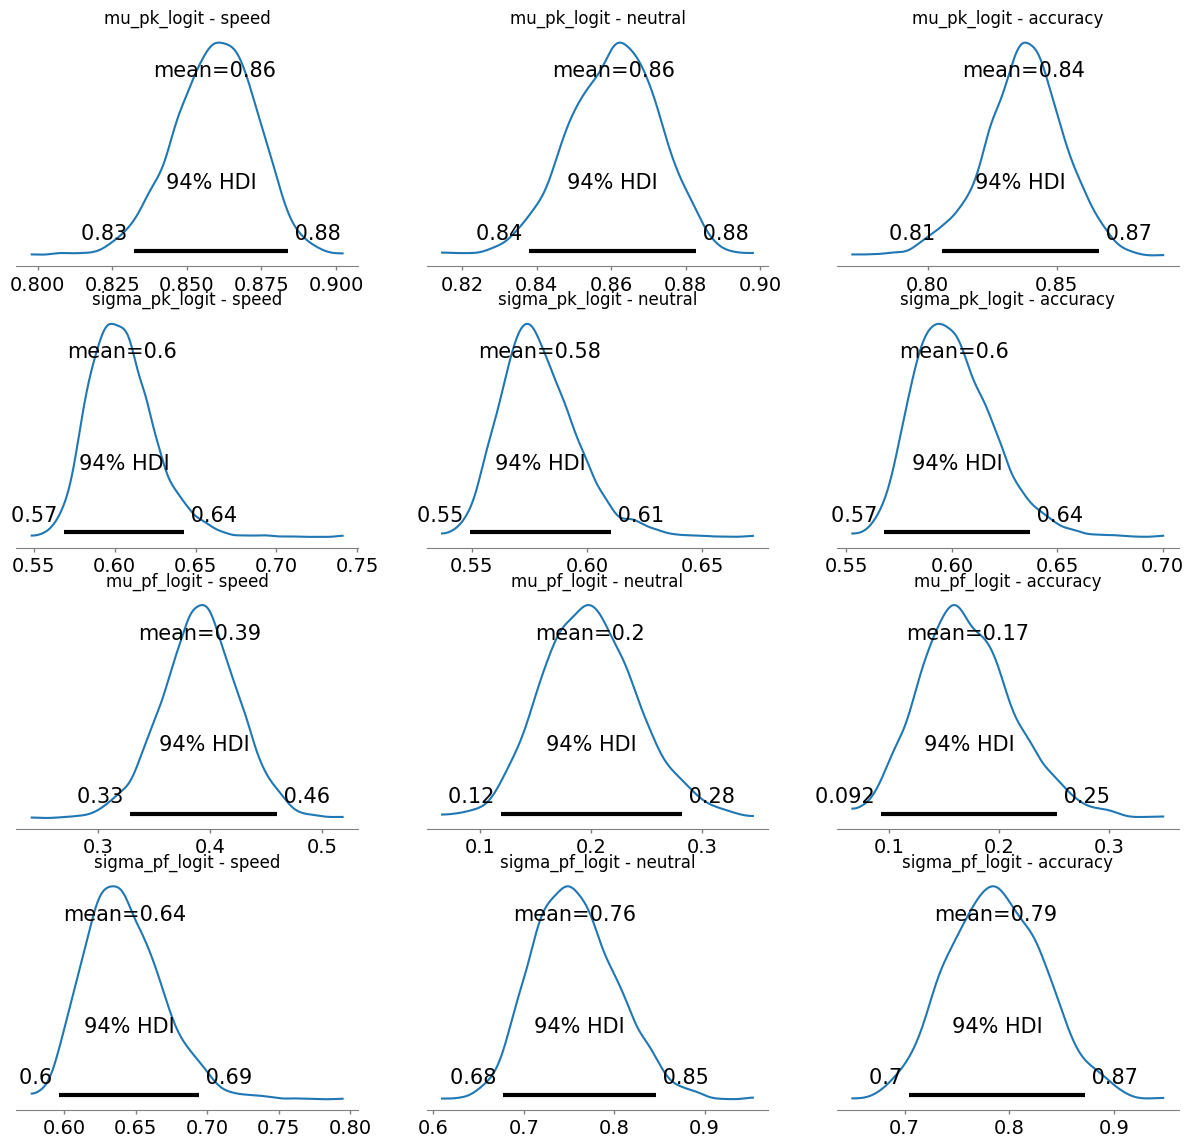

In [29]:
cond_labels = ["speed", "neutral", "accuracy"]
hyper_pairs_percond = [("mu_pk_logit", "sigma_pk_logit"), ("mu_pf_logit", "sigma_pf_logit"),('mu_logB','sigma_logB')]
hyper_scalars = [
    ("mu_logr", "sigma_logr"),
    ("mu_t0_logit", "sigma_t0_logit"), ("mu_lapse_logit", "sigma_lapse_logit"),
]





transforms = {
    "mu_pk_logit": expit, "sigma_pk_logit": expit,
    "mu_logB": np.exp, "sigma_logB": None,
    "mu_pf_logit": expit, "sigma_pf_logit": expit,
    "mu_logr": np.exp, "sigma_logr": None,
    "mu_t0_logit": expit, "sigma_t0_logit": None,
    "mu_lapse_logit": expit, "sigma_lapse_logit": None,
}

fig, axes = plt.subplots(4, 3, figsize=(15, 14))
row = 0
for mu_var, sigma_var in hyper_pairs_percond:
    for var in (mu_var, sigma_var):
        dim = f"{var}_dim_0"
        for j, cond in enumerate(cond_labels):
            az.plot_posterior(idata, var_names=[var], coords={dim: [j]},
                               transform=transforms[var], ax=axes[row, j])
            axes[row, j].set_title(f"{var} - {cond}")
        row += 1
plt.tight_layout()

fig2, axes2 = plt.subplots(2, 4, figsize=(20, 8))
axes2 = axes2.flatten()
for i, var in enumerate([v for pair in hyper_scalars for v in pair]):
    az.plot_posterior(idata, var_names=[var], transform=transforms[var], ax=axes2[i])
    axes2[i].set_title(var)
plt.tight_layout()
plt.show()

In [34]:
import scipy
pk,pf = 0.86,0.39
c = -(scipy.stats.norm.ppf(pk) + scipy.stats.norm.ppf(pf))/2
d = scipy.stats.norm.ppf(pk) - scipy.stats.norm.ppf(pf)
print(c,d)
pk,pf = 0.86,0.2
c = -(scipy.stats.norm.ppf(pk) + scipy.stats.norm.ppf(pf))/2
d = scipy.stats.norm.ppf(pk) - scipy.stats.norm.ppf(pf)
print(c,d)
pk,pf = 0.84,0.17
c = -(scipy.stats.norm.ppf(pk) + scipy.stats.norm.ppf(pf))/2
d = scipy.stats.norm.ppf(pk) - scipy.stats.norm.ppf(pf)
print(c,d)

-0.4005001531837509 1.35963837526241
-0.11934905362102083 1.92194057438787
-0.020146315031779494 1.9486231363559474


TypeError: 'Axes' object is not subscriptable

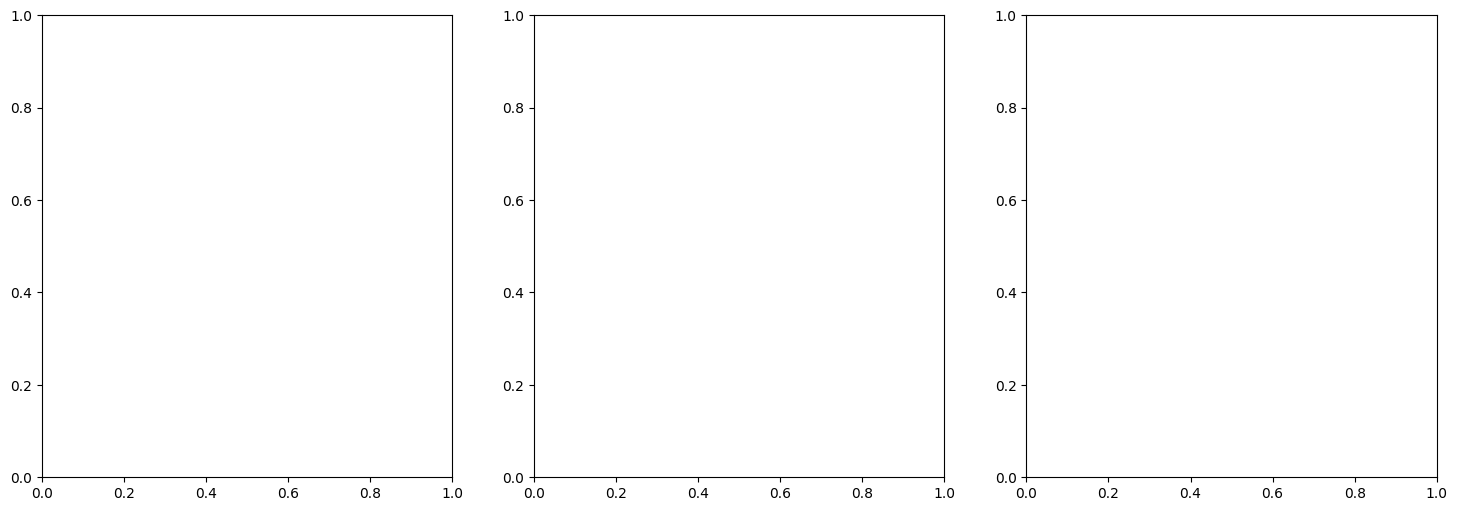

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for j, cond in enumerate(cond_labels):
    az.plot_pair(
        idata,
        var_names=["mu_pk_logit", "mu_pf_logit"],
        coords={"mu_pk_logit_dim_0": [j], "mu_pk_logit_dim_0": [j]},
        kind="scatter",
        divergences=True,
        ax=axes[j],
    )
    axes[j].set_title(f"mu_c vs mu_logd - {cond}")

plt.tight_layout()
plt.show()

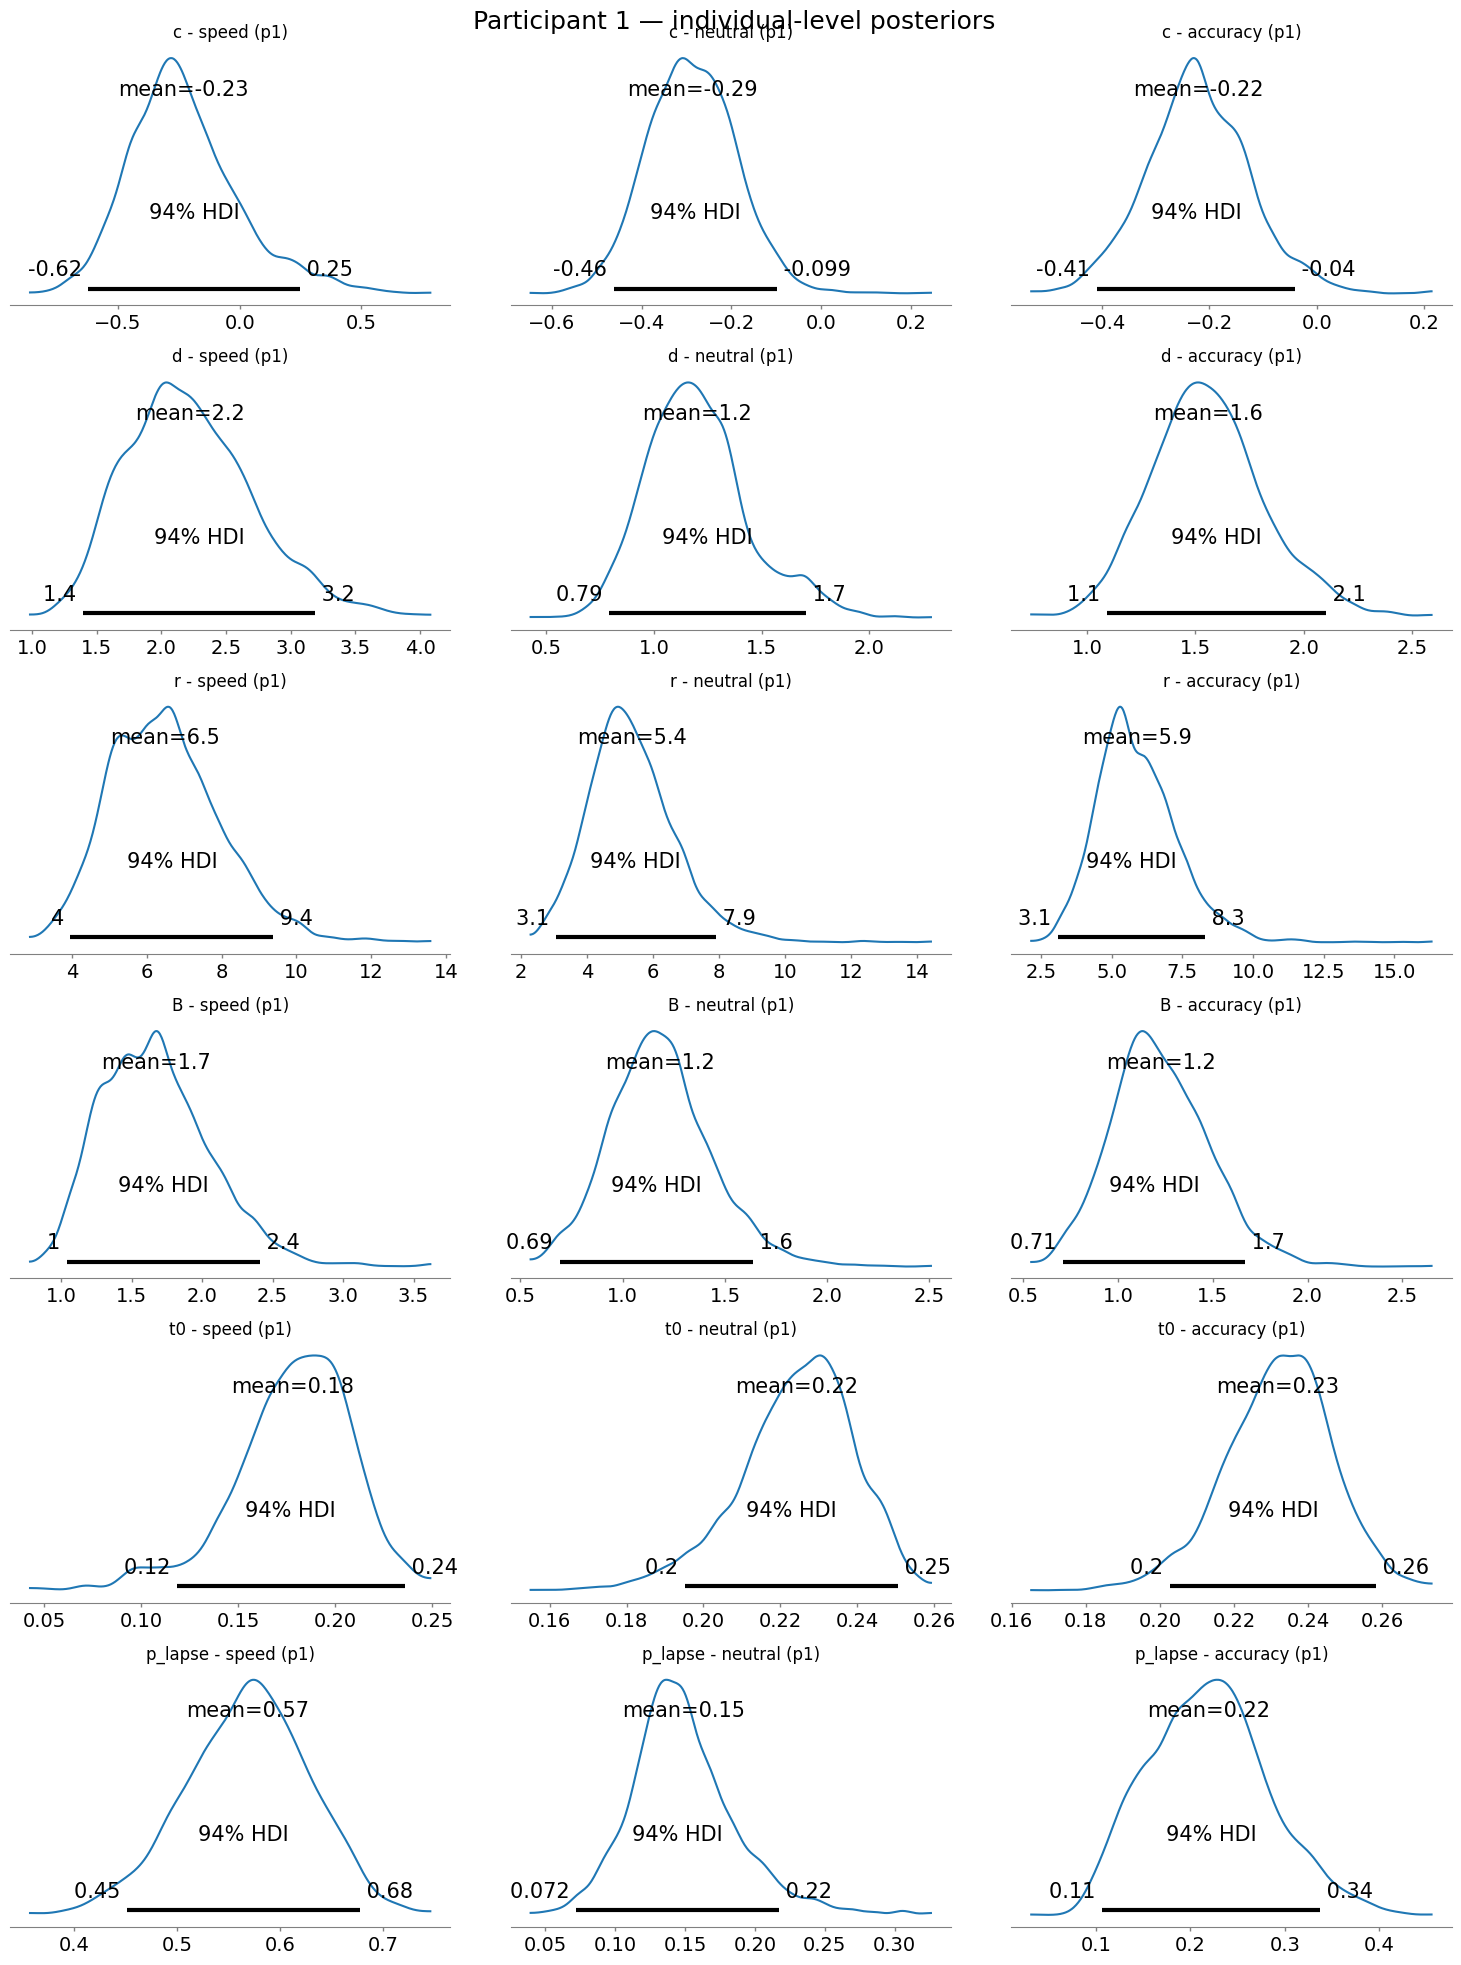

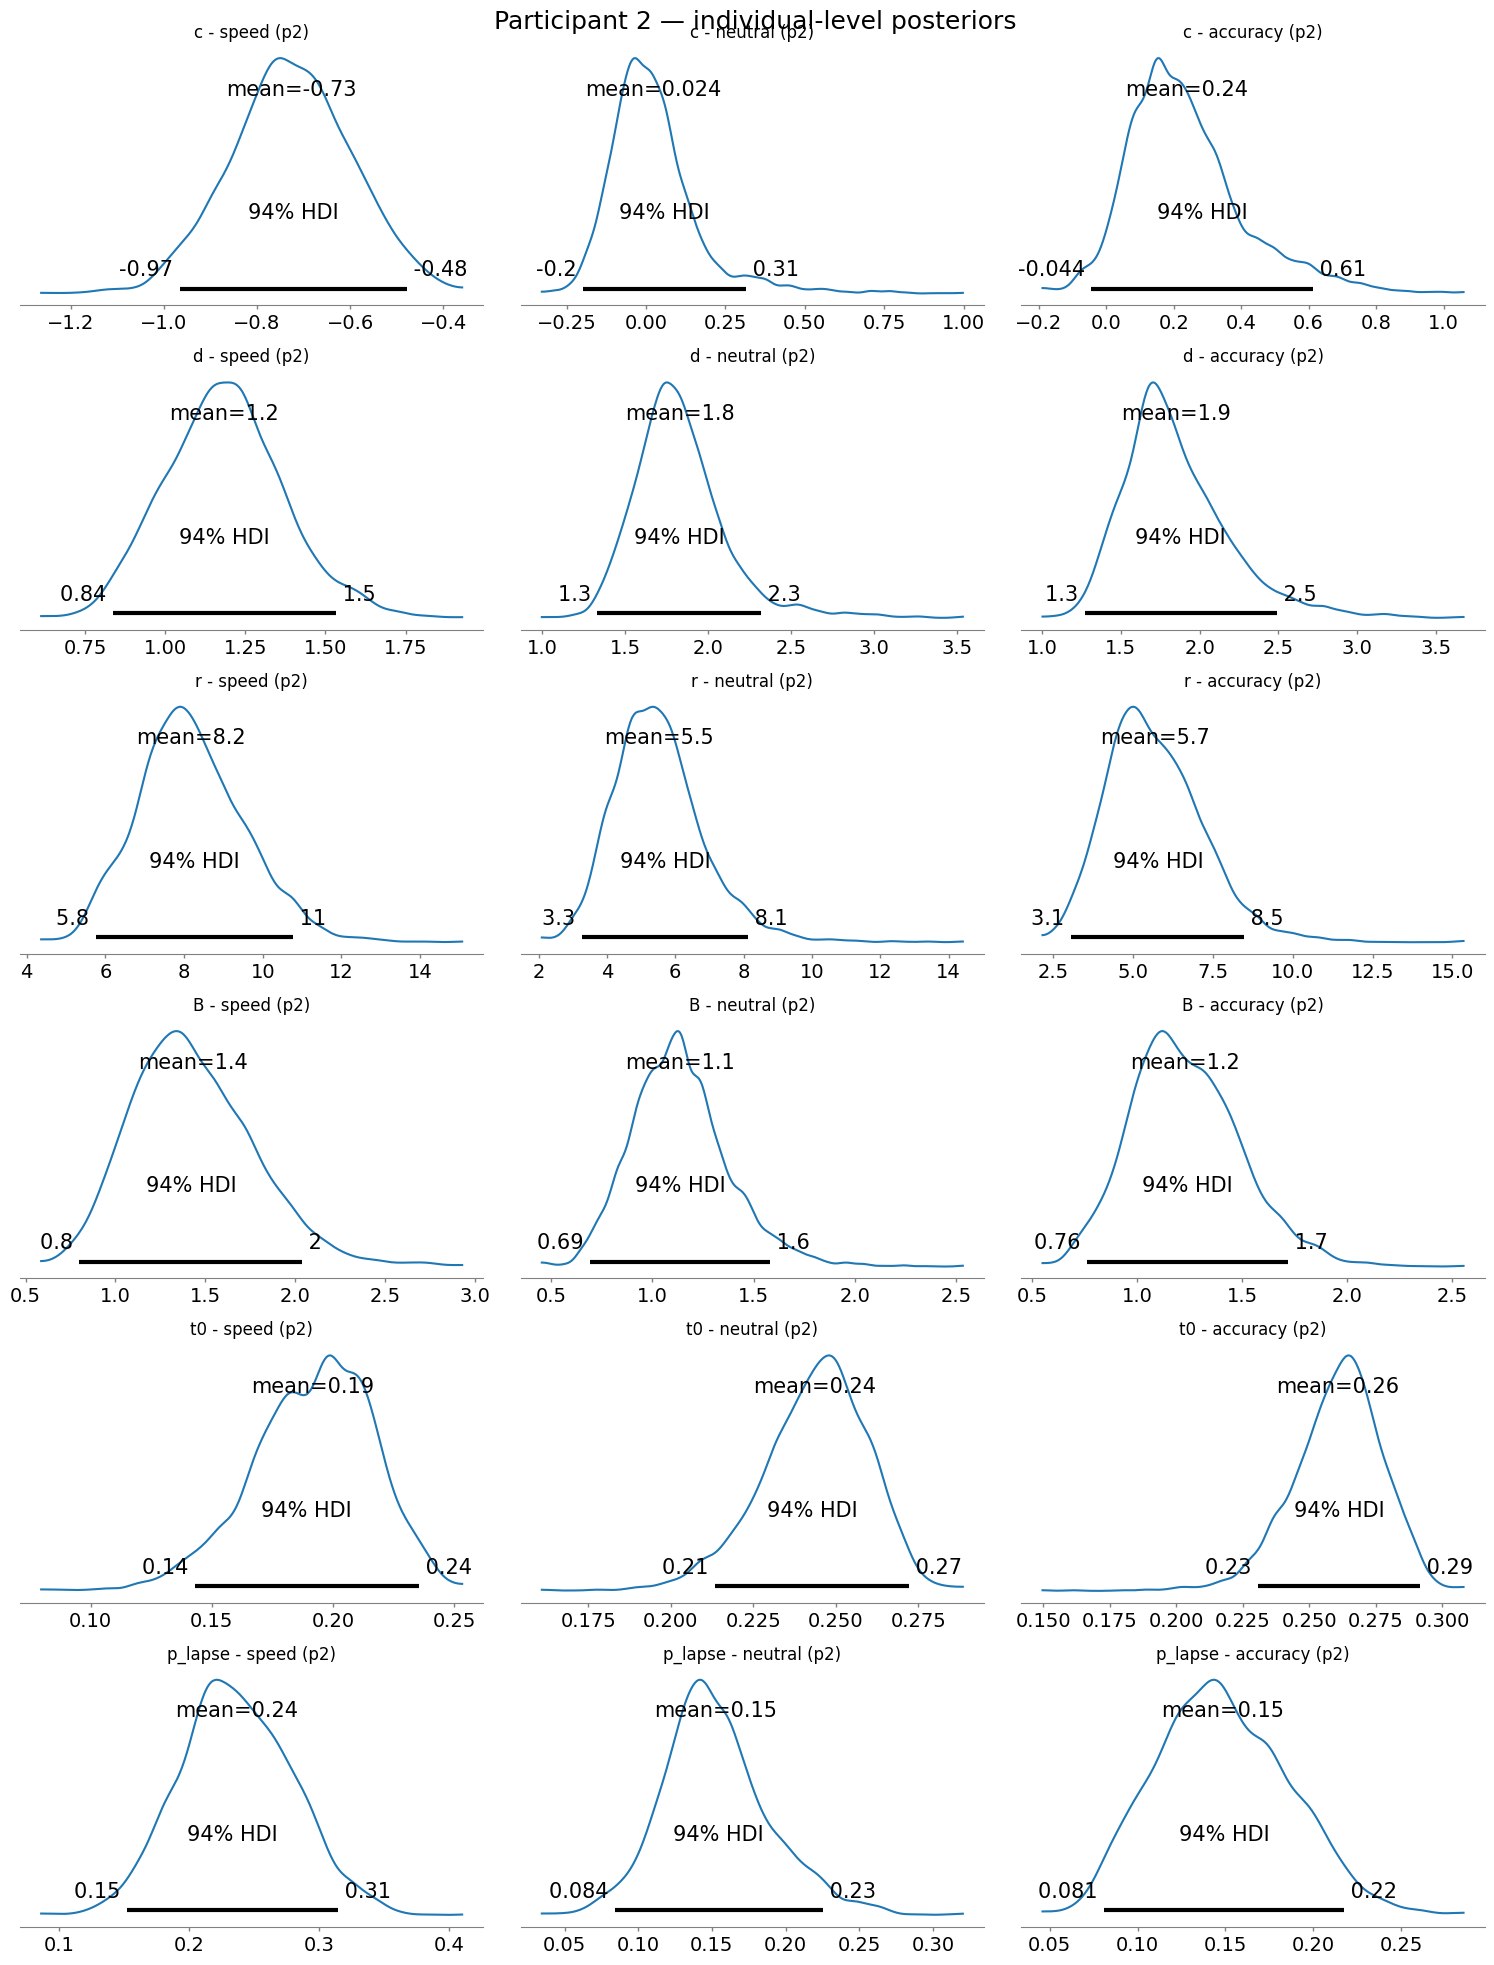

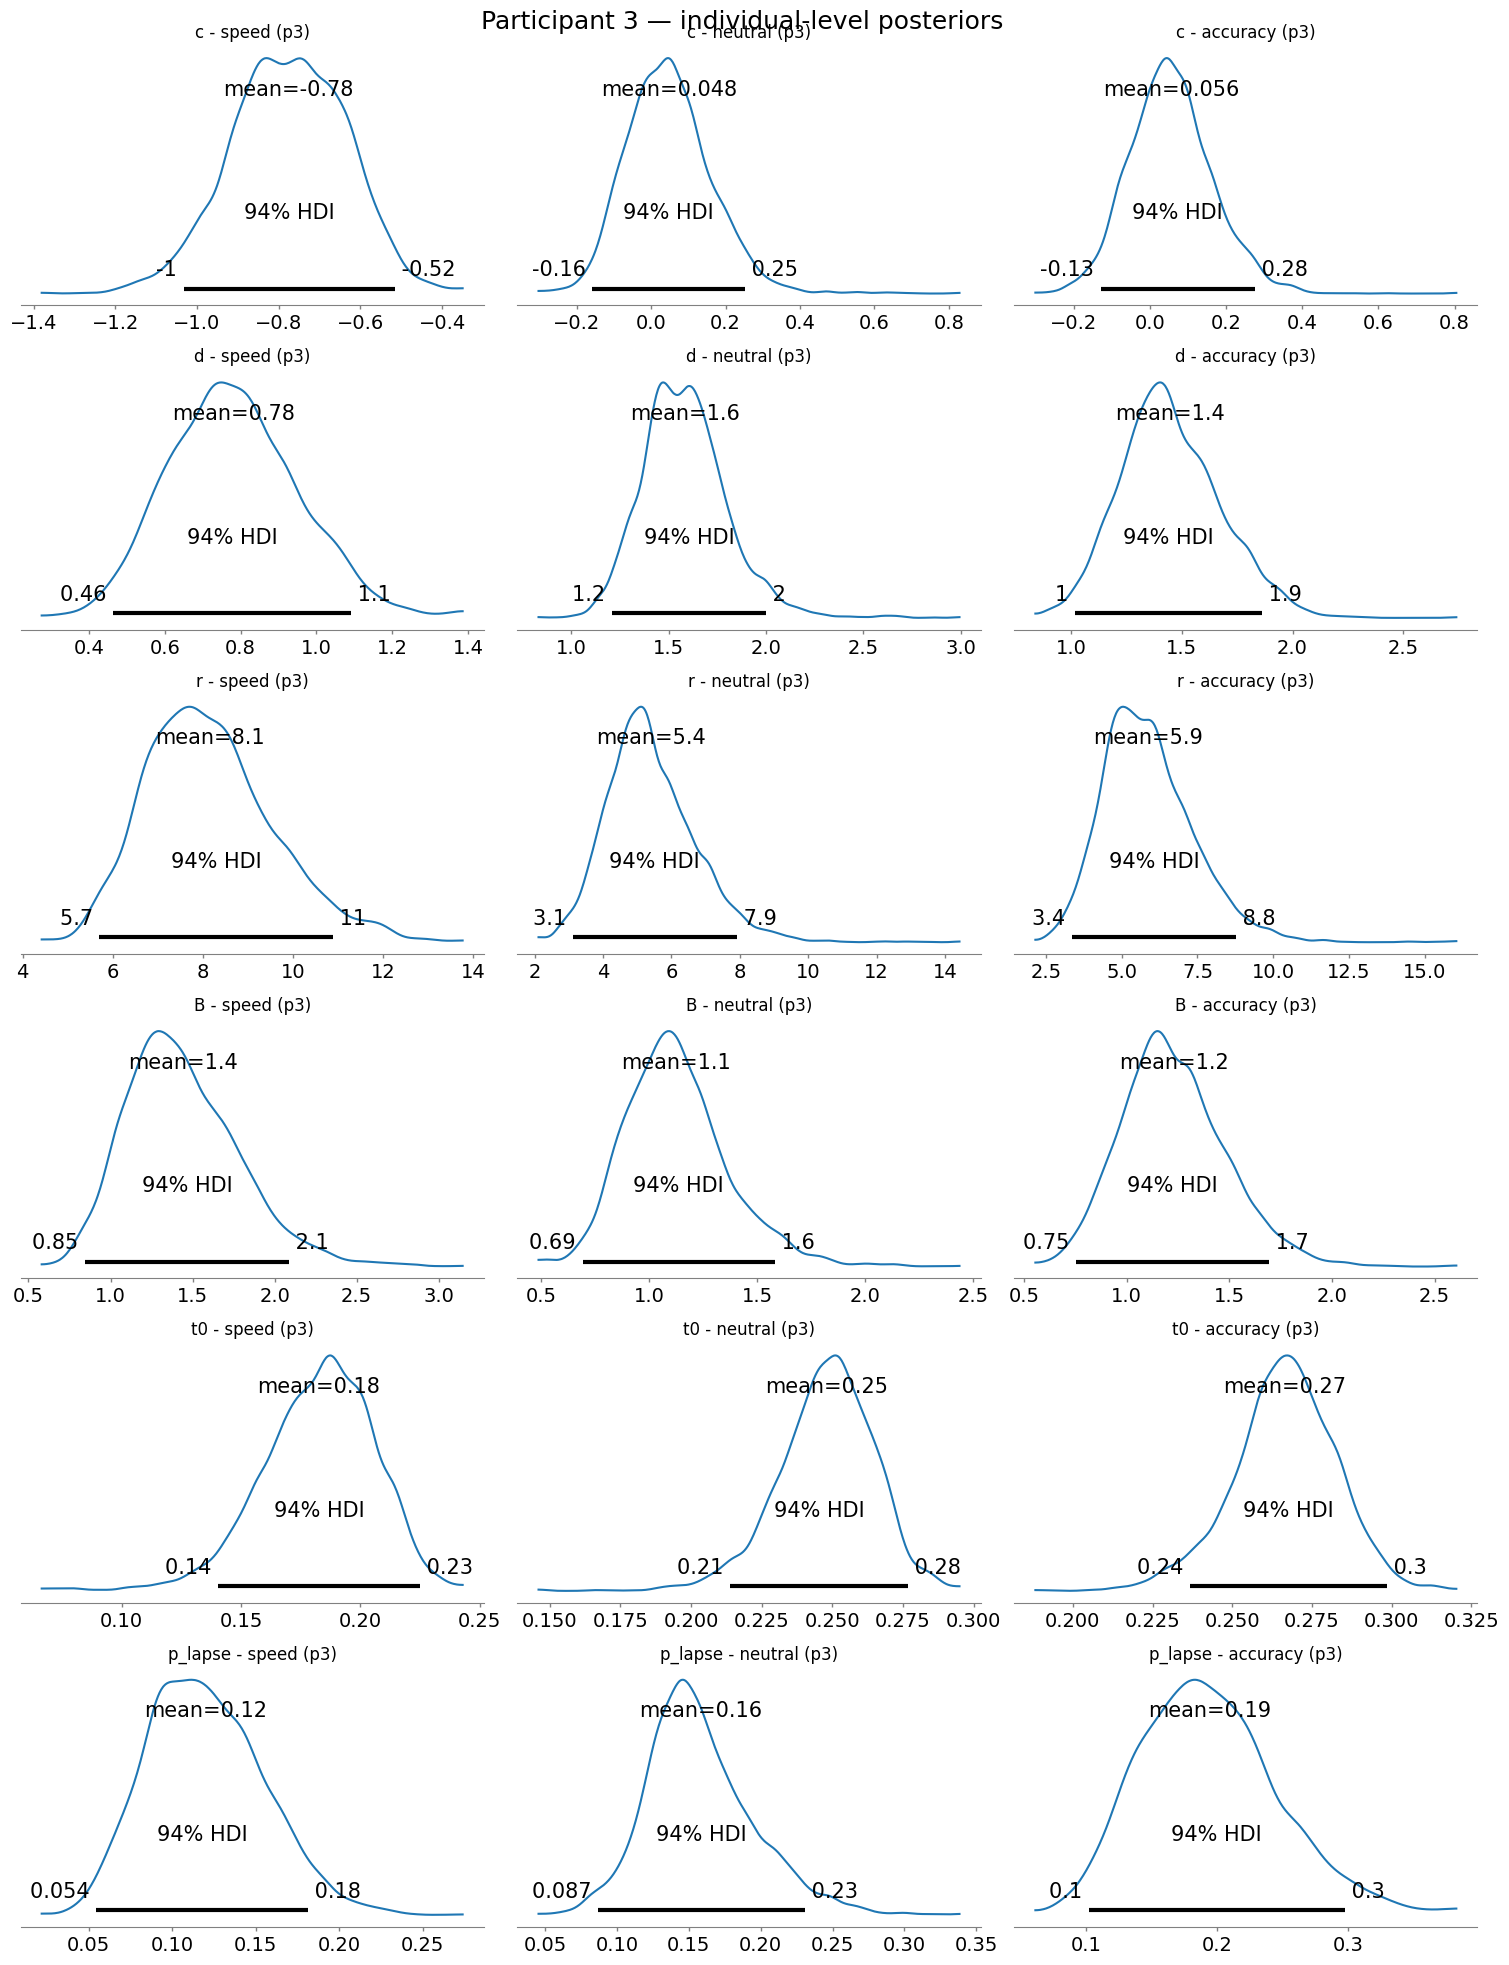

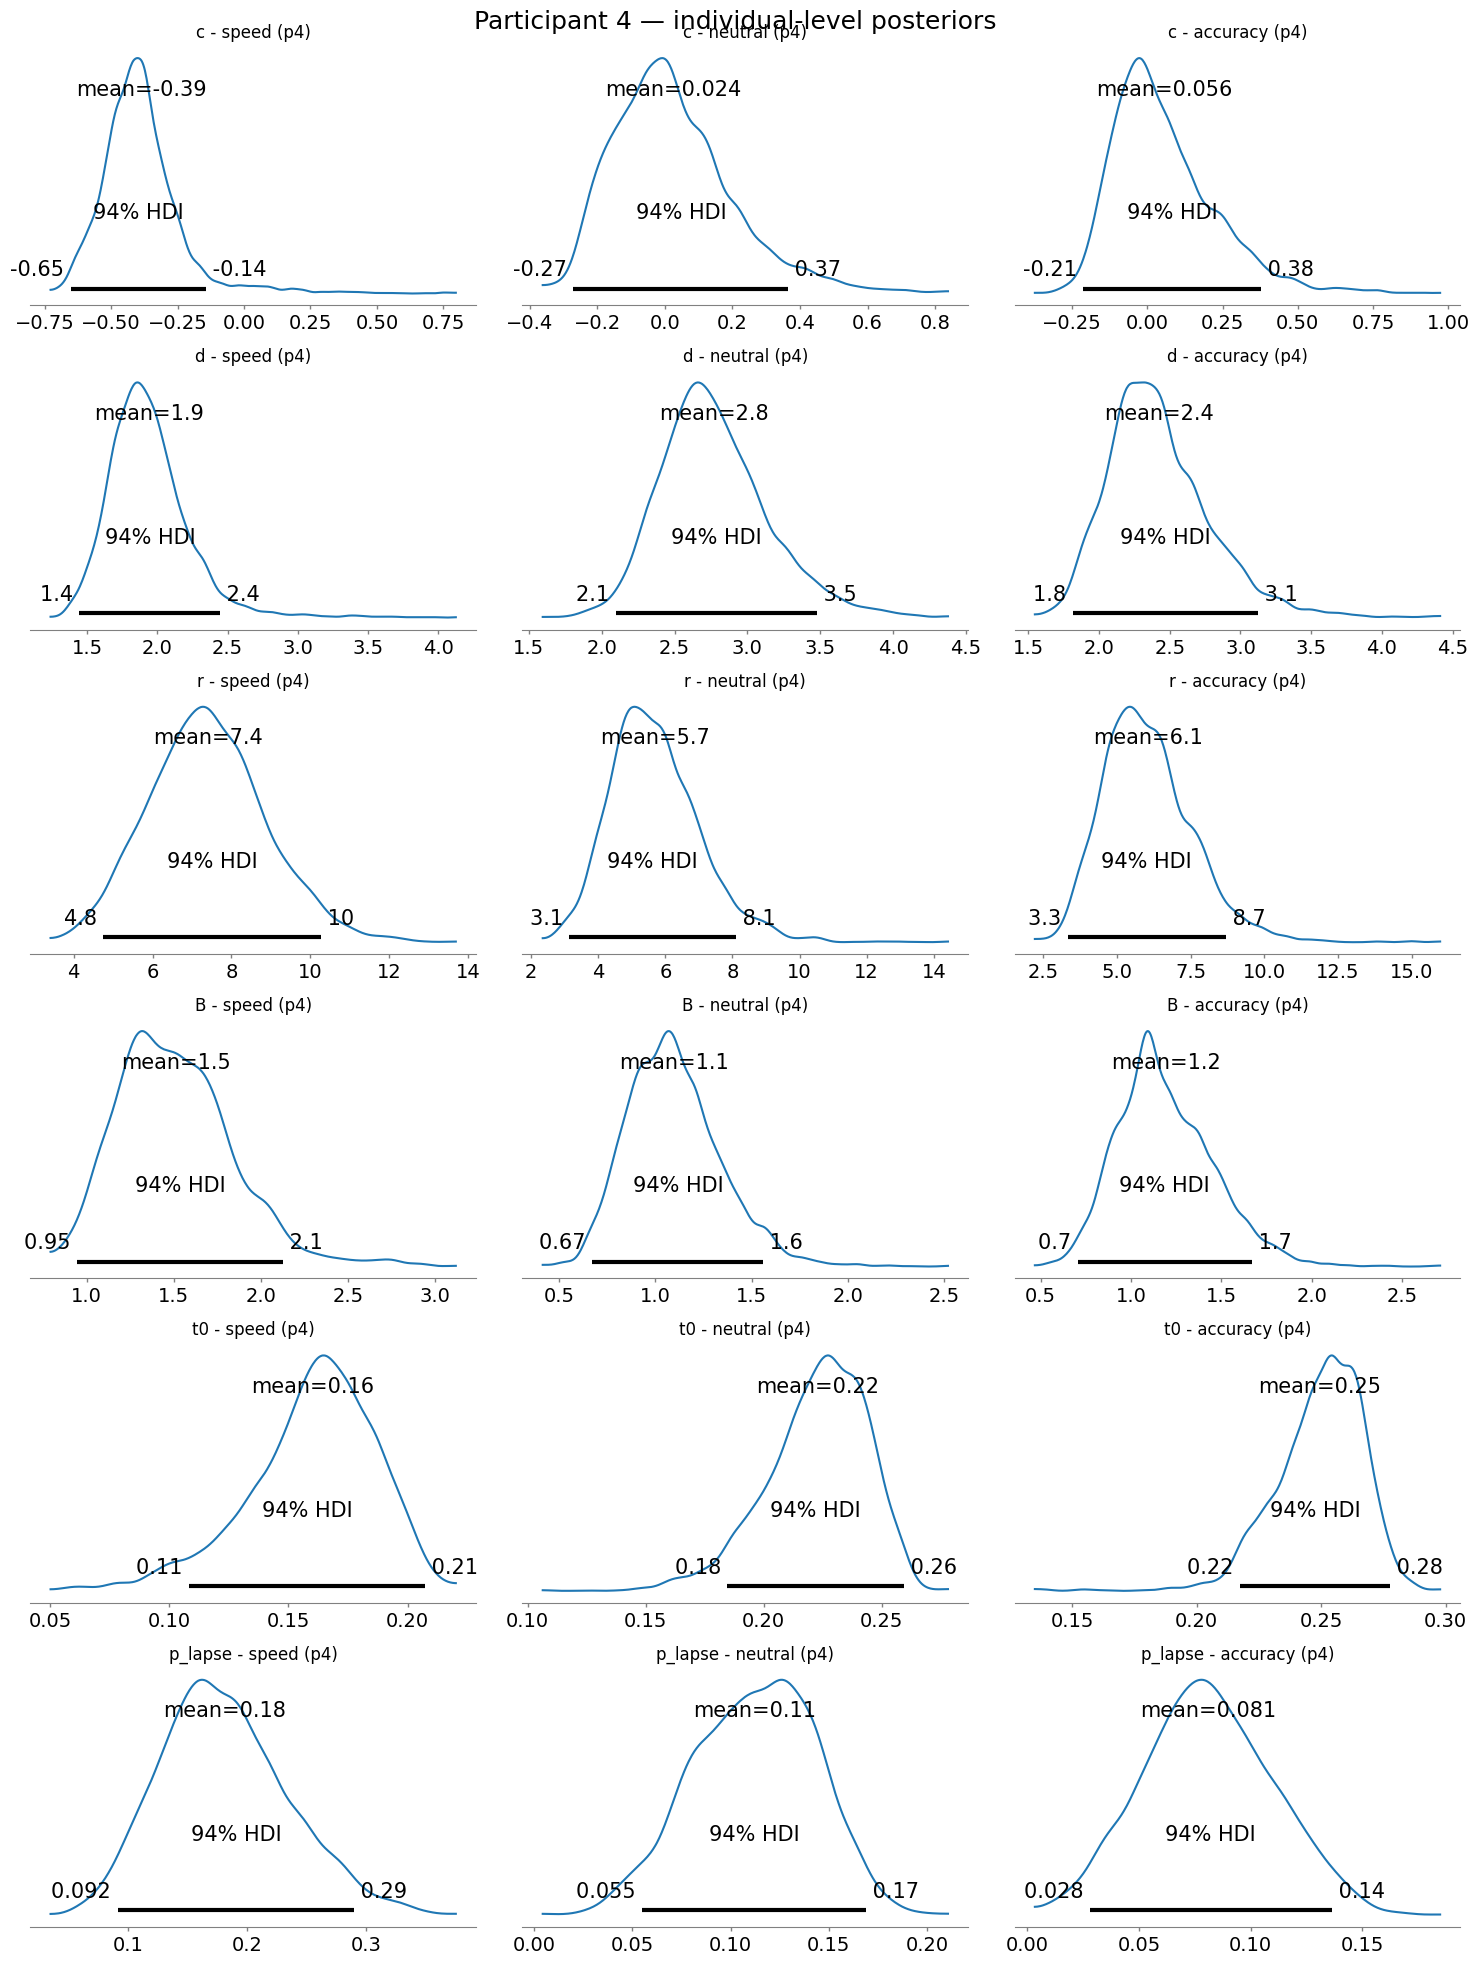

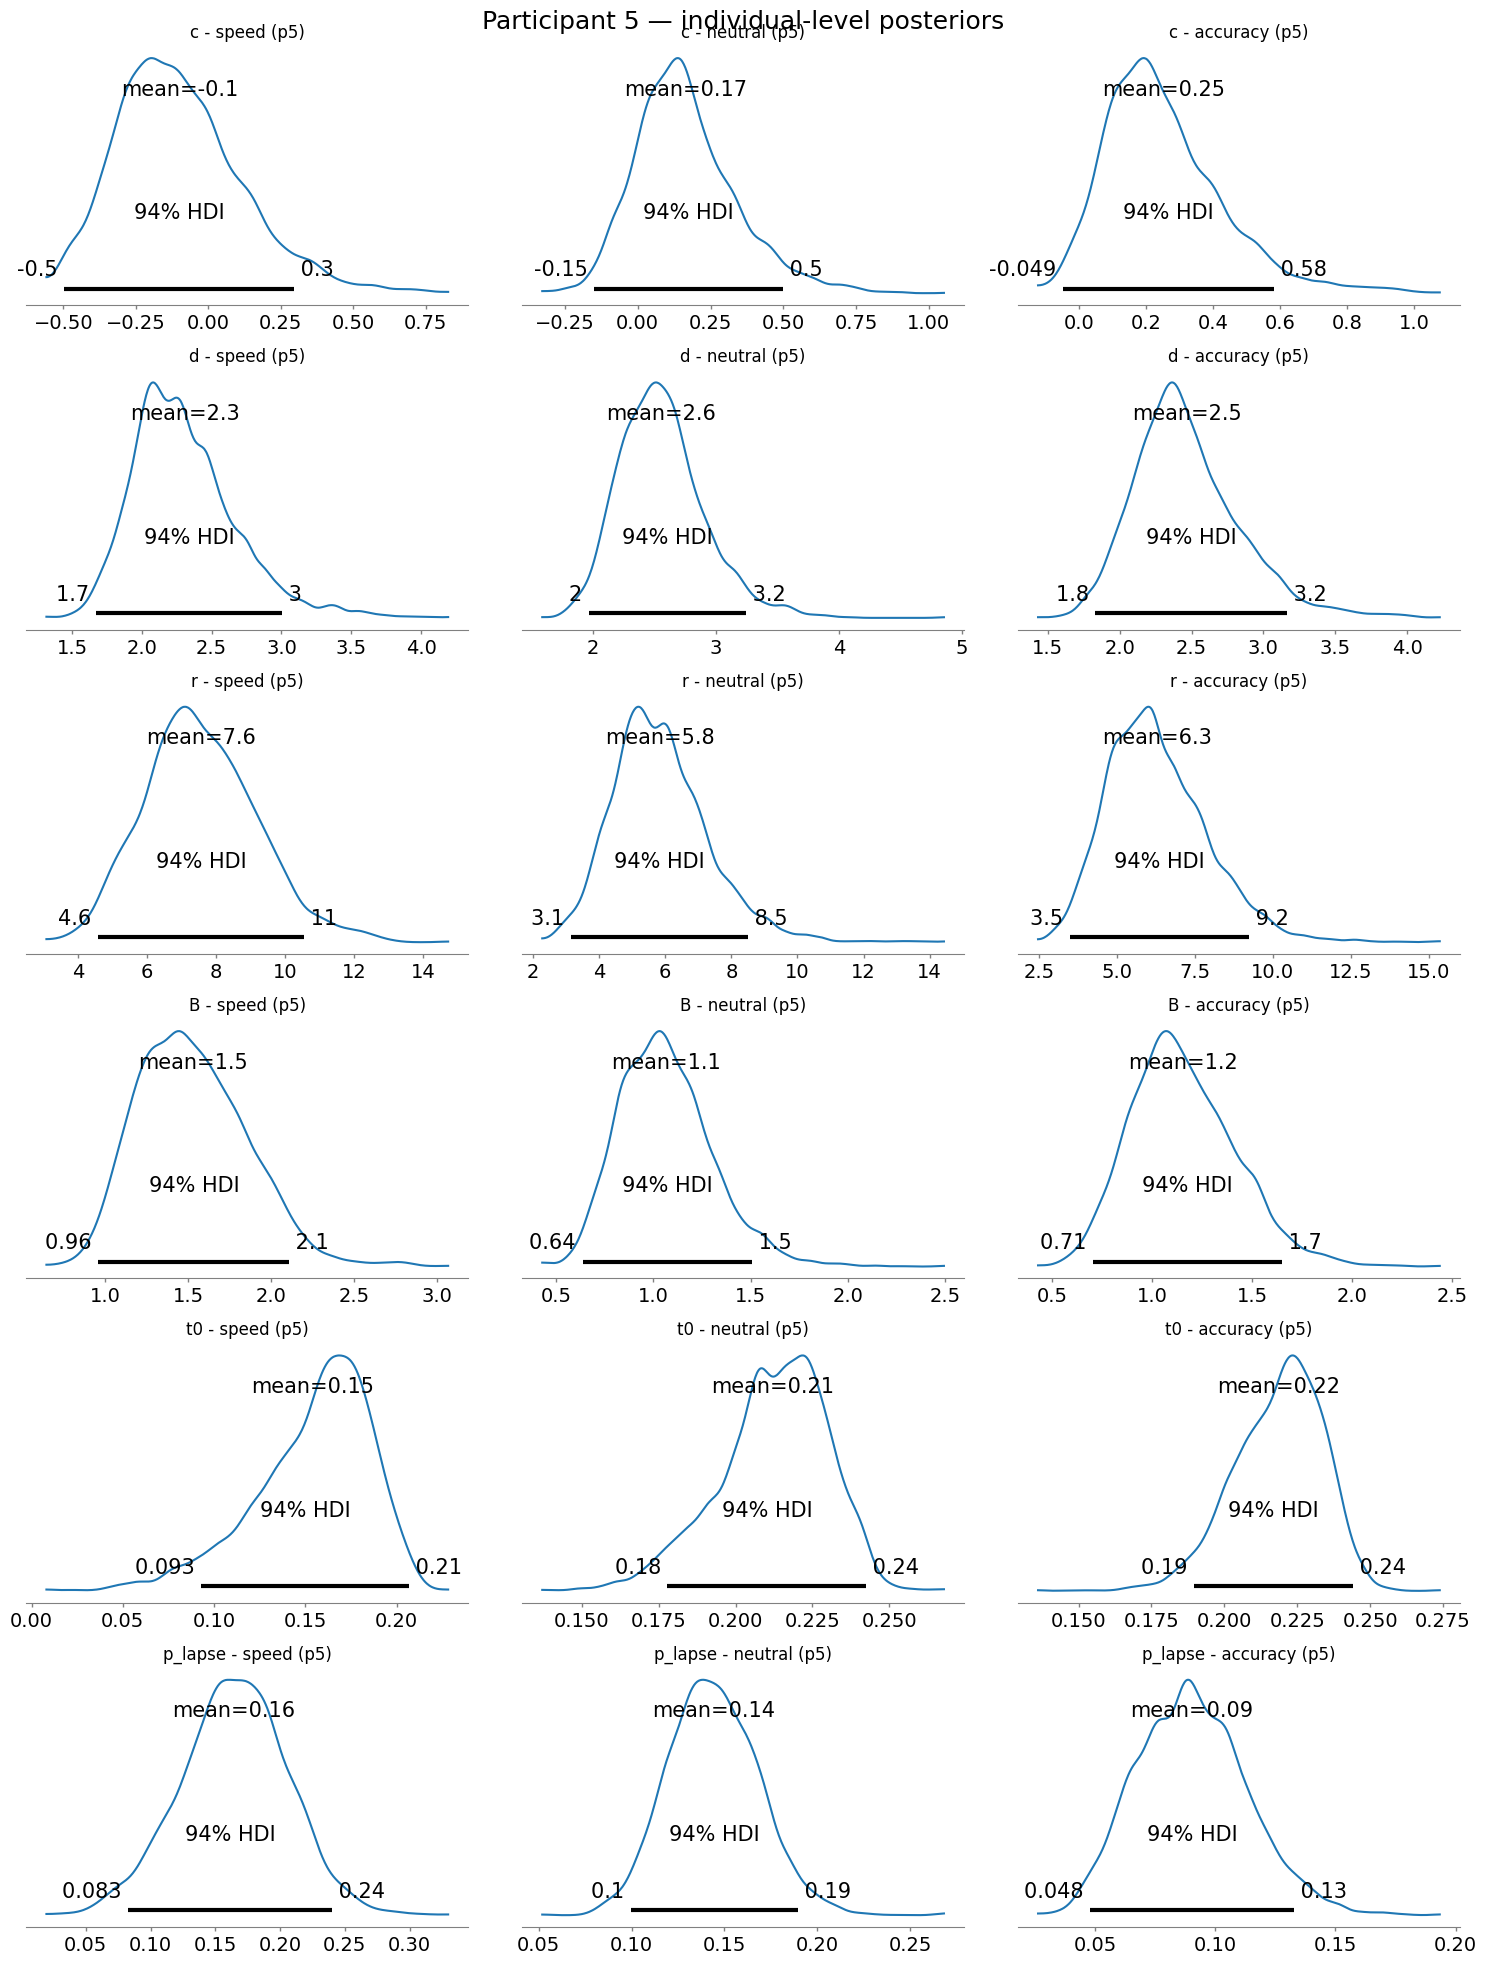

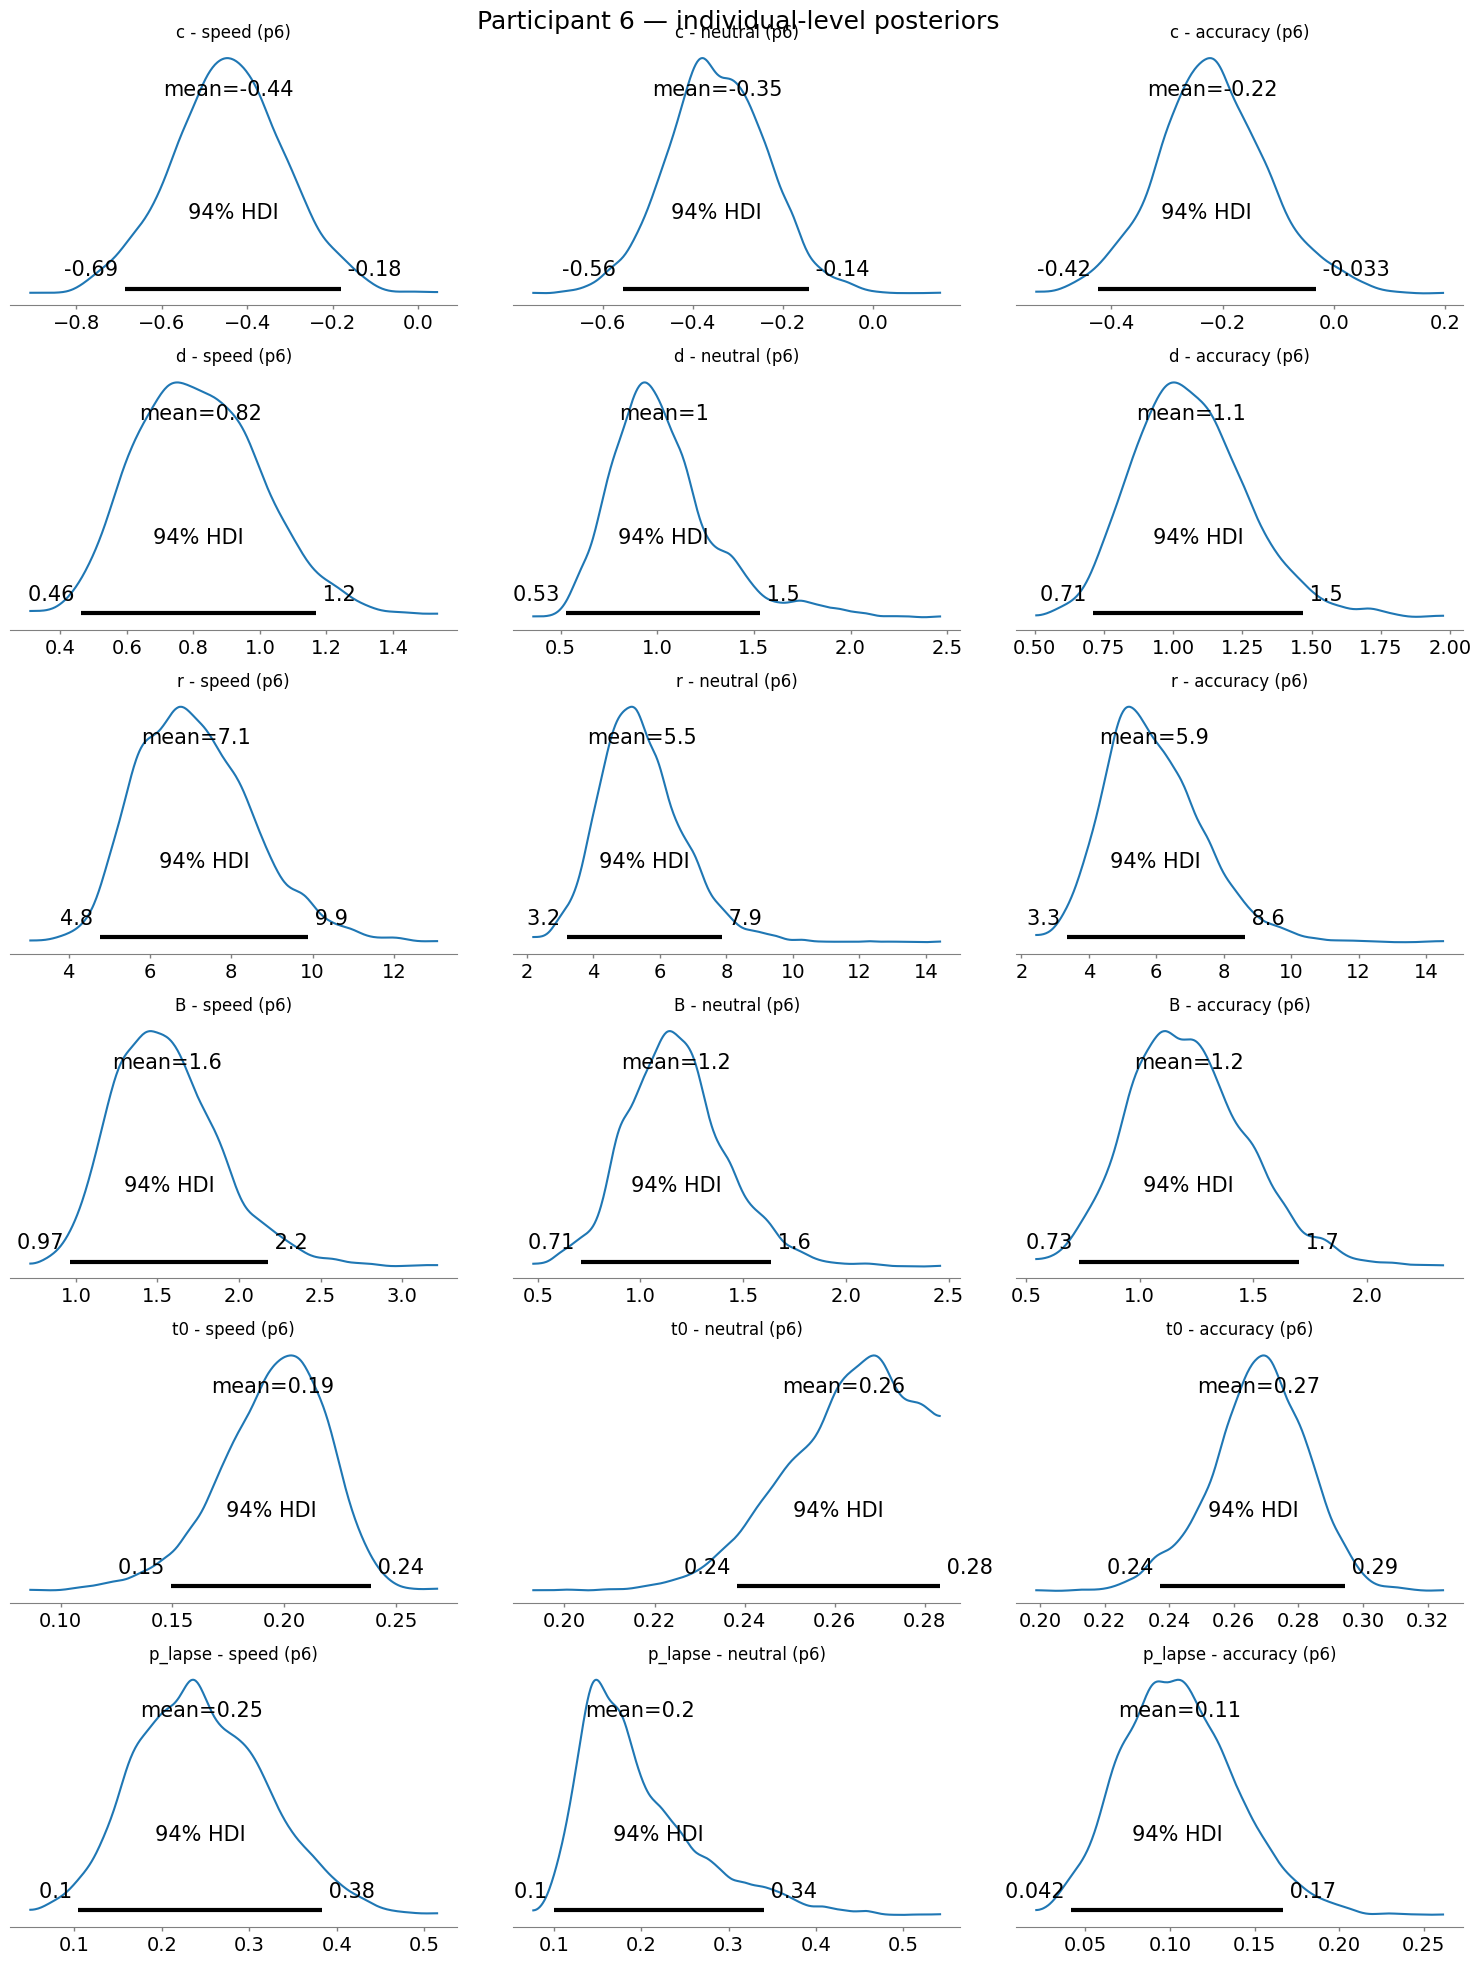

KeyError: 'Coords should follow mapping format {coord_name:[dim1, dim2]}. Check that coords structure is correct and dimensions are valid. "not all values found in index \'c_dim_0\'"'

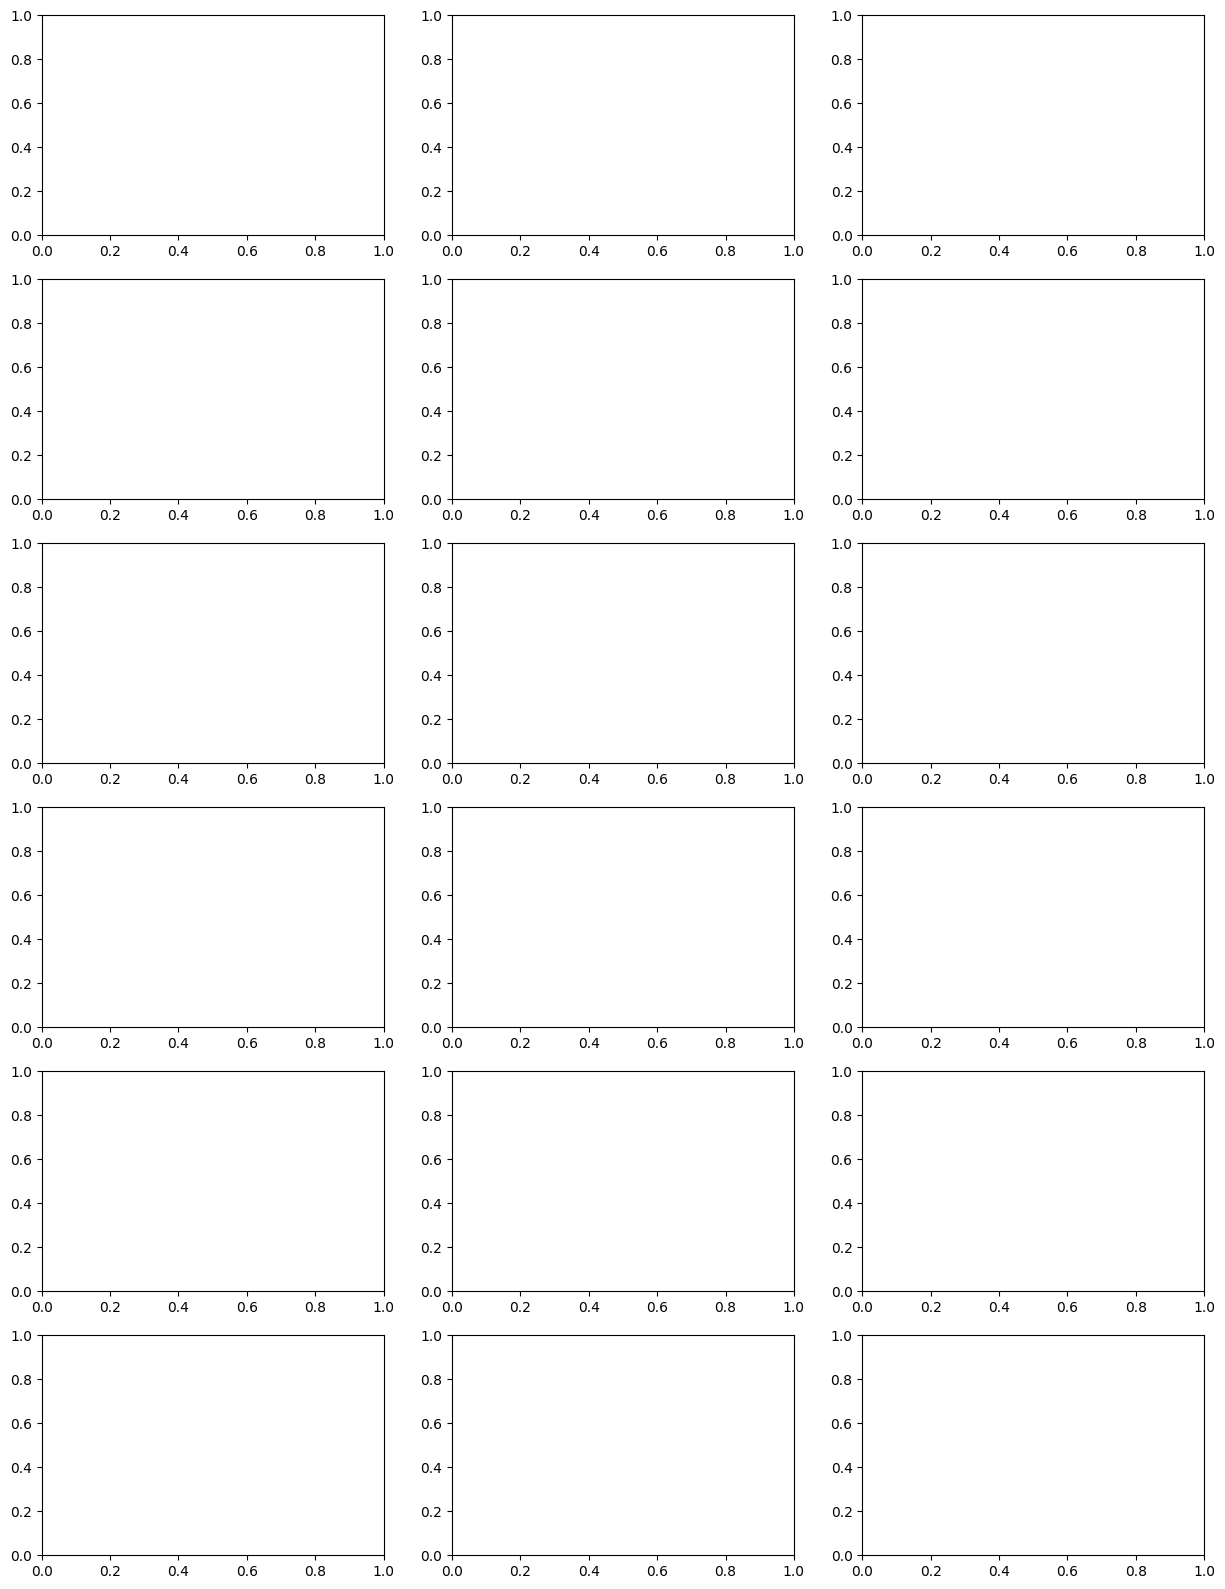

In [ ]:
n_participants = 19
per_cell_vars = ["c", "d", "r", "B", "t0", "p_lapse"]  # all 3*P now, no separate scalar group

for p in range(n_participants):
    fig, axes = plt.subplots(6, 3, figsize=(15, 20))
    idx = [p*3, p*3+1, p*3+2]

    for row, var in enumerate(per_cell_vars):
        dim = f"{var}_dim_0"
        for j, cond in enumerate(cond_labels):
            az.plot_posterior(idata, var_names=[var], coords={dim: [idx[j]]}, ax=axes[row, j])
            axes[row, j].set_title(f"{var} - {cond} (p{p+1})")

    fig.suptitle(f"Participant {p+1} — individual-level posteriors", fontsize=18)
    plt.tight_layout()
    plt.show()